/tmp/ipykernel_4252/3024429064.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


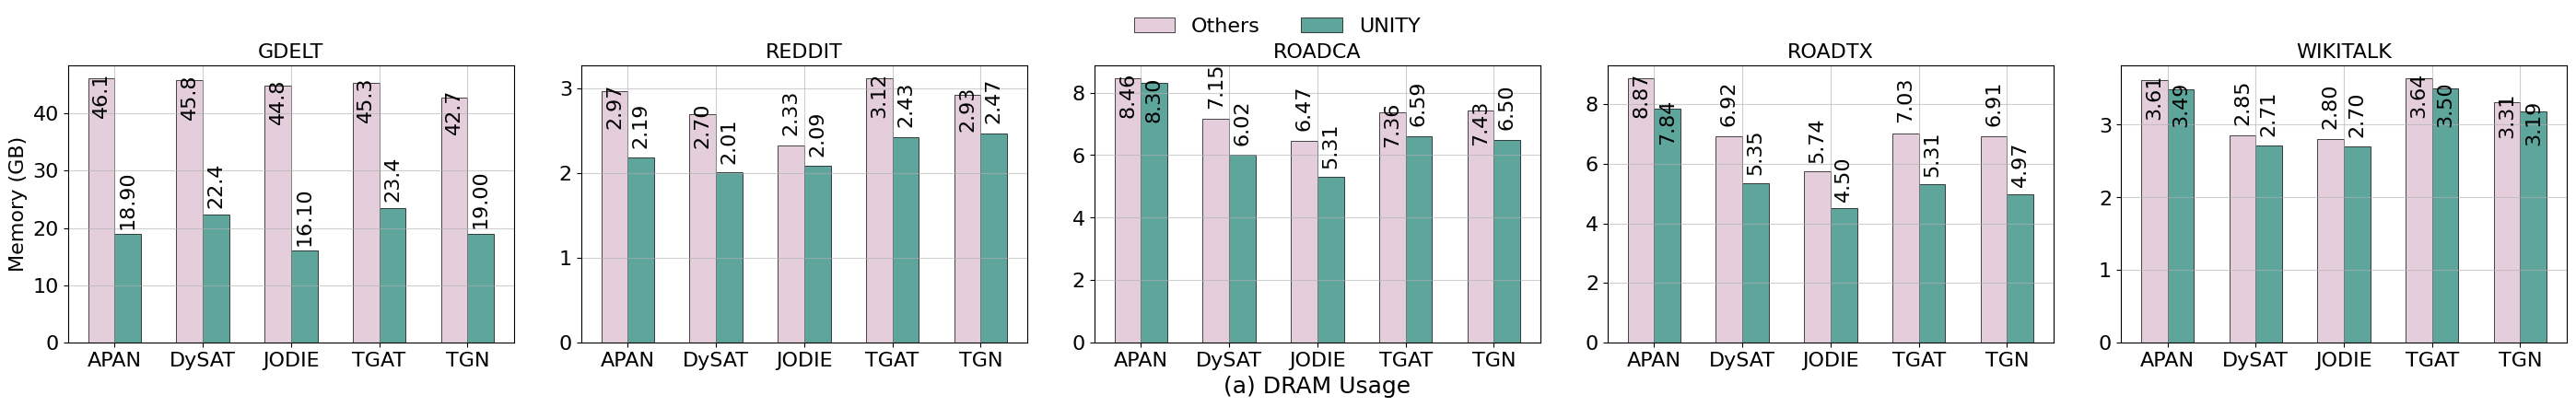

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
import yaml
from matplotlib import gridspec

plt.rc('font', size=16)
plt.rc('axes', titlesize=12)

# 配置参数
hardware_configs = ['(a) DRAM Usage']  # 只保留第二行的硬件配置
datasets = ['GDELT', 'REDDIT', 'ROADCA', 'ROADTX', 'WIKITALK']
algorithms = ['APAN', 'DySAT', 'JODIE', 'TGAT', 'TGN']
baseline_labels = ['Others', 'UNITY']  # 只保留两种方法

# 生成模拟数据 (2硬件配置 × 5数据集 × 5算法 × 2方法)
mem_yaml_files = ["memory_nolimit.yaml", "memory.yaml"]

# 定义硬件配置名称
data = {}

# 只读取第二个硬件配置的 YAML 数据
hw = hardware_configs[0]  # 只获取 (b) Minimal DRAM 配置
yaml_file = mem_yaml_files[1]  # 对应的 YAML 文件是 "memory.yaml"
with open(yaml_file, "r") as file:
    yaml_data = yaml.safe_load(file)  # 读取 YAML 数据

formatted_data = {}
for dataset, models in yaml_data.items():
    formatted_data[dataset] = {}
    for model, values in models.items():
        # 提取 Others 和 UniTGL，并存入列表
        formatted_data[dataset][model] = [values["Others"], values["UNITY"]]

data[hw] = formatted_data

# 创建总图
fig = plt.figure(figsize=(35, 9))  # 调整总图高度
outer_gs = gridspec.GridSpec(2, 1, hspace=0.3)  # 2行布局

# 颜色配置（两种方法）
colors = ['#1f77b4', '#2ca02c']  # baseline1蓝色，ours绿色
import mycolors
colors = [mycolors.MALOPE.PURPLE, mycolors.LADDER_ORDER.LIGHT_GREEN]

# 只处理第二行（Minimal DRAM）的数据
for row_idx, hardware in enumerate(hardware_configs):
    inner_gs = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=outer_gs[row_idx], wspace=0.15)
    
    # 添加硬件配置标题
    outer_pos = outer_gs[row_idx].get_position(fig)
    fig.text((outer_pos.x0 + outer_pos.x1)/2, outer_pos.y0 - 0.04, hardware,
             ha='center', va='top', fontsize=18)

    # 遍历每个数据集
    for col_idx, dataset in enumerate(datasets):
        ax = fig.add_subplot(inner_gs[col_idx])
        
        # 设置x轴位置
        x_base = np.arange(len(algorithms))
        bar_width = 0.3  # 加宽柱子宽度

        # 绘制两种方法
        for method_idx in range(2):
            x_offset = x_base + (method_idx - 0.5) * bar_width  # 对称分布
            values = [data[hardware][dataset][algo][method_idx] for algo in algorithms]
            
            bars = ax.bar(x_offset, values, width=bar_width,
                        color=colors[method_idx],
                        edgecolor='black', 
                        linewidth=0.5,
                        label=baseline_labels[method_idx] if col_idx == 0 else "")

            # 添加数据标签
            for bar in bars:
                height = bar.get_height()
                label_height = height * 1.05
                if label_height > ax.get_ylim()[1]*0.85:  # 如果超出了 y 轴范围
                    label_height = height * 0.85  # 将标签放在柱子顶端的下方
                if height < 20:
                    ax.text(bar.get_x() + bar.get_width()/2., label_height,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=16, rotation=90)
                else:
                    ax.text(bar.get_x() + bar.get_width()/2., label_height,
                        f'{height:}', ha='center', va='bottom', fontsize=16, rotation=90)

        # 设置子图属性
        ax.set_title(dataset, fontsize=16)
        ax.set_xticks(x_base)
        ax.set_xticklabels(algorithms, rotation=0, ha='center',fontsize=16)
        ax.grid(True, which='both', linestyle='-', alpha=0.6)

        if col_idx == 0:
            ax.set_ylabel('Memory (GB)',fontsize=16)

# 添加统一图例
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center',
           ncol=2, bbox_to_anchor=(0.5, 0.96),
           fontsize=16, frameon=False)

plt.tight_layout()
plt.savefig('exp2.pdf', bbox_inches='tight')
plt.show()
